<a href="https://colab.research.google.com/github/dheofyd0120-cmd/Opt_project_3_RL/blob/main/RL_problem1_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from __future__ import annotations
import random
from typing import Optional
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from gymnasium import spaces

class PlainMazeEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array", "human"], "render_fps": 4}
    ACTIONS = ["left", "right", "forward"]

    def __init__(self, max_steps: int = 100):
        super().__init__()
        self.max_steps = max_steps
        self.width = 8
        self.height = 8

        # Define Action Space (0: Turn Left, 1: Turn Right, 2: Move Forward)
        self.action_space = spaces.Discrete(3)

        # Define Observation Space matching standard MiniGrid image wrapper
        self.observation_space = spaces.Dict({
            "image": spaces.Box(low=0, high=255, shape=(64, 64, 3), dtype=np.uint8),
            "direction": spaces.Discrete(4)
        })

        # Fixed 8x8 maze layout with outer wall padding
        self.layout = [
            "WWWWWWWW",
            "W...W..W",
            "W.W.W.WW",
            "W...W..W",
            "WWW.W..W",
            "W.....WW",
            "W.WWW.GW",
            "WWWWWWWW",
        ]

        self.grid = np.zeros((self.height, self.width), dtype=np.int32)
        self._build_grid()

        self.start = (1, 1)
        self.goal = (6, 6)

        # Variables required for Tabular RL tracking (env.agent_pos, env.agent_dir)
        self.agent_pos = list(self.start)
        self.agent_dir = 0  # 0: Right, 1: Down, 2: Left, 3: Up
        self.steps = 0
        self.terminated = False
        self.truncated = False

    def _build_grid(self):
        for y, row in enumerate(self.layout):
            for x, ch in enumerate(row):
                if ch == "W": self.grid[y, x] = 1   # Wall
                elif ch == "G": self.grid[y, x] = 2  # Goal
                else: self.grid[y, x] = 0           # Path

    def reset(self, seed: Optional[int] = None, options=None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.agent_pos = list(self.start)
        self.agent_dir = 0
        self.steps = 0
        self.terminated = False
        self.truncated = False

        return self._get_obs(), {}

    def step(self, action: int):
        if self.terminated or self.truncated:
            raise RuntimeError("Episode has ended. Call reset() to start a new episode.")

        # Agent orientation and forward movement dynamics
        if action == 0:   # Left
            self.agent_dir = (self.agent_dir - 1) % 4
        elif action == 1: # Right
            self.agent_dir = (self.agent_dir + 1) % 4
        elif action == 2: # Forward
            new_pos = self._forward_pos()
            # Collision handling with maze walls
            if self.grid[new_pos[1], new_pos[0]] != 1:
                self.agent_pos = list(new_pos)
        else:
            raise ValueError(f"Unknown action: {action}")

        self.steps += 1

        # Reward shaping: Time penalty (-0.01) to optimize for the shortest path
        reward = -0.01
        self.terminated = (self.agent_pos[0] == self.goal[0] and self.agent_pos[1] == self.goal[1])
        self.truncated = self.steps >= self.max_steps

        if self.terminated:
            reward = 1.0

        # Complies with standard 5-tuple Gymnasium output unpacking
        return self._get_obs(), reward, self.terminated, self.truncated, {}

    def _forward_pos(self):
        # Maps coordinates based on standardized orientation vectors
        dx, dy = [(1, 0), (0, 1), (-1, 0), (0, -1)][self.agent_dir]
        return (self.agent_pos[0] + dx, self.agent_pos[1] + dy)

    def _get_obs(self):
        # Synchronizes dictionary keys with tabular Q-learning and Deep RL template scripts
        return {
            "image": self.render(mode="rgb_array"),
            "direction": self.agent_dir
        }

    def render(self, mode: str = "rgb_array"):
        # Scale the grid cells into a 64x64 buffer for CNN inputs
        cell_size = 8
        img = np.zeros((self.height * cell_size, self.width * cell_size, 3), dtype=np.uint8)

        colors = {
            0: (30, 30, 30),     # Path: Dark Gray
            1: (150, 150, 150), # Wall: Light Gray
            2: (0, 255, 0),     # Goal: Green
        }

        for y in range(self.height):
            for x in range(self.width):
                c = colors[int(self.grid[y, x])]
                img[y * cell_size : (y + 1) * cell_size, x * cell_size : (x + 1) * cell_size] = c

        # Render Agent position (Red block)
        ax, ay = self.agent_pos
        img[ay * cell_size : (ay + 1) * cell_size, ax * cell_size : (ax + 1) * cell_size] = (255, 0, 0)

        if mode == "human":
            fig, axplot = plt.subplots(figsize=(4, 4))
            axplot.imshow(img)
            axplot.axis("off")
            plt.show()
            plt.close(fig) # Prevent display memory leaks in Jupyter notebooks

        return img

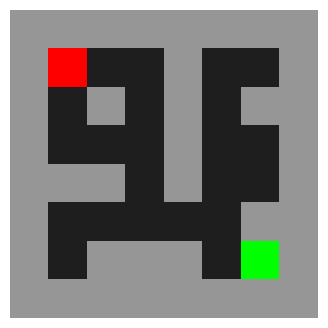

array([[[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       ...,

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]]], dtype=uint8)
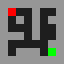

In [3]:
# 1. Initialize the maze environment instance
env = PlainMazeEnv(max_steps=100)

# 2. Reset the environment before making any steps or rendering
obs, info = env.reset(seed=42)

# 3. Render the maze visually on the screen (human mode)
env.render(mode="human")